# Initialization

## Package Imports

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import root_mean_squared_error

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import copy
import random

import warnings
from sklearn.exceptions import ConvergenceWarning

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Constants

In [ ]:
SEED = 102800
k_VAL = 4

## Data Set Import

In [ ]:
# df_train = pd.read_csv("/content/drive/MyDrive/B556_Raw_Data/possum_filtered_train.csv")
# df_test = pd.read_csv("/content/drive/MyDrive/B556_Raw_Data/possum_filtered_test.csv")
df = pd.read_csv("/content/drive/MyDrive/B556_Raw_Data/possum_filtered.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pop       85 non-null     object 
 1   sex       85 non-null     object 
 2   age       85 non-null     int64  
 3   hdlngth   85 non-null     float64
 4   skullw    85 non-null     float64
 5   totlngth  85 non-null     float64
 6   taill     85 non-null     float64
 7   footlgth  85 non-null     float64
 8   earconch  85 non-null     float64
 9   eye       85 non-null     float64
 10  chest     85 non-null     float64
 11  belly     85 non-null     float64
dtypes: float64(9), int64(1), object(2)
memory usage: 8.1+ KB


!!! This is an experiment done at the end of the assignment. I want to see how reducing the dataset to just one sex affects the final prediction. This will probably work horribly given how small the dataset already is. I'm choosing to focus on males since they have the larger sub-dataset.

UPDATE: As noted at the end, this actually *improved* the accuracy of the model. I suppose that means that, with binomial distributions as I was seeing, breaking up the model and running separate regressions makes more sense.

In [ ]:
# df = df[df['sex'] == 'm']

In [ ]:
df.describe()

,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,3.988235,92.612941,56.492941,87.261176,36.970588,68.303529,48.284706,15.040000,26.905882,32.511765
std,1.899211,2.773205,2.072656,3.600334,1.572367,4.445609,4.157967,0.984547,1.785347,2.416432
min,1.000000,85.900000,51.000000,80.500000,33.500000,60.300000,41.300000,12.800000,23.000000,27.000000
25%,3.000000,91.000000,55.000000,85.000000,36.000000,64.400000,44.800000,14.400000,25.500000,31.000000
50%,4.000000,92.800000,56.300000,88.000000,37.000000,67.900000,47.000000,15.000000,27.000000,32.000000
75%,5.000000,94.400000,57.900000,89.500000,38.000000,72.500000,52.000000,15.700000,28.000000,34.000000
max,9.000000,99.900000,61.500000,95.500000,40.500000,77.200000,56.200000,17.400000,31.000000,38.500000


# Part D
**Train a Linear Regression model using the training data with four-fold cross-validation and with appropriate evaluation metric. Do this with a closed-form solution (using the Normal Equation or SVD) and with SGD. Then focus on SGD and perform Ridge, Lasso and Elastic Net regularization – try three values of penalty term and describe its impact. Explore the impact of other hyperparameters of your choice, such as learning rate (no need for grid search). Describe your findings. Select the best-performing regularization set of hyperparameters and train that model on the entire training dataset. For SGD, display the training and validation loss as a function of training epochs for the selected model. (Hint: In scikit-learn, max_iter counts epochs (full passes over the training set). To plot training/validation loss by epoch with SGDRegressor, set max_iter=1 and warm_start=True, then call fit(...) in a loop; after each call (each epoch), compute and record Train and Validation RMSE). Ensure reproducibility by using a seed.**

The data is already cleaned through R. We will be targeting the *age* using the remaining variables after OneHotEncoding the categorical variables.

ChatGPT assisted OneHotEncoding

## One Hot Encoding

In [ ]:
cat_features = ['Pop', 'sex']
num_features = df.columns.difference(cat_features)

# Converting categorical variables to OneHotEncoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop=None), cat_features),
        ('num', 'passthrough', num_features)
    ]
)

df_onehot = preprocessor.fit_transform(df)

In [ ]:
# Get new column names from the encoder
encoded_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)

# Combine encoded and numeric column names
final_columns = list(encoded_cols) + list(num_features)

# Convert to DataFrame
df_onehot = pd.DataFrame(df_onehot, columns=final_columns)


In [ ]:
df_onehot.head()

,Pop_Vic,Pop_other,sex_f,sex_m,age,belly,chest,earconch,eye,footlgth,hdlngth,skullw,taill,totlngth
0,1.0,0.0,0.0,1.0,8.0,36.0,28.0,54.5,15.2,74.5,94.1,60.4,36.0,89.0
1,1.0,0.0,1.0,0.0,6.0,33.0,28.5,51.2,16.0,72.5,92.5,57.6,36.5,91.5
2,1.0,0.0,1.0,0.0,6.0,34.0,30.0,51.9,15.5,75.4,94.0,60.0,39.0,95.5
3,1.0,0.0,1.0,0.0,6.0,34.0,28.0,52.2,15.2,76.1,93.2,57.1,38.0,92.0
4,1.0,0.0,1.0,0.0,2.0,33.0,28.5,53.2,15.1,71.0,91.5,56.3,36.0,85.5


In [ ]:
# create feature matrix and target
df = df_onehot
features = df.columns.delete(4)
target = "age"

X = df[features]
y = df[target]

Defining 80-20 Training-Test split in data

In [ ]:
TEST_SPLIT = 0.20
VAL_SPLIT = 0.25

We do the Training-Test split here, but then we will further divide Training into Training AND Validation.

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=SEED)


We perform the train-test split, then we perform scaling. The fit is established on the TRAINING set then applied to BOTH the training AND test sets. This is done to maintain the test set's neutrality since otherwise its presence would be felt (since its values would've affected scaling even though they are absent from the training set).

In [ ]:
# Scales data such that x̄ = 0, σ = 1 using StandardScaler
def scale_data(X_train, X_test):
  scaler = StandardScaler()
  scaler.fit(X_train)

  X_train_scaled = scaler.transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # convert back to pd DF and keep the feature names and row indices
  X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
  X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
  return X_train_scaled, X_test_scaled

In [ ]:
# X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

We only scale X, not y. This is because normalization is to make numerical processing easier and prevent values with arbitrarily large scales from having more impact by default. However, since we are trying to predict y, we want to keep it unscaled lest we have to do some form of unscaling post-processing.

## Cross-Validation

We generate four training-validation splits to compare against one another to control for distributions of values in each subset.

In [ ]:
random.seed(SEED)

# 4-fold cross validation
cv = KFold(n_splits=k_VAL, shuffle=True, random_state=SEED)

In [ ]:
# Function to create average RMSE from cross validation with 4 folds for a model
def create_cross_validation_list(model, degree=1):
  '''Enter model with parameters, returns list with the 4 fold
  cross validation RMSE results'''

  cv_results = []

  for train_index, validation_index in cv.split(X_train):
    # -------------
    # Extracting training and validation sets based on Cross-Validation split
    # -------------
    X_train_fold = X_train.iloc[train_index]
    y_train_fold = y_train.iloc[train_index]

    X_val_fold = X_train.iloc[validation_index]
    y_val_fold = y_train.iloc[validation_index]

    # -------------
    # Scaling features
    # -------------
    X_train_fold_scaled, X_val_fold_scaled = scale_data(X_train_fold, X_val_fold)

    # -------------
    # OPTIONAL: Polynomial Expansion of the Features Set (degree >= 2)
    # -------------
    poly = PolynomialFeatures(degree = degree)
    X_train_fold_scaled = poly.fit_transform(X_train_fold_scaled)
    X_val_fold_scaled = poly.transform(X_val_fold_scaled)

    # -------------
    # Fit the model to the training set, then predict on the validation set
    # -------------
    model.fit(X_train_fold_scaled, y_train_fold)
    y_pred = model.predict(X_val_fold_scaled)

    # -------------
    # Track RMSE for this fold
    # -------------
    rmse = root_mean_squared_error(y_val_fold, y_pred)
    cv_results.append(rmse)

  return(float(round(np.mean(cv_results), k_VAL)))




## Closed-Form Linear Regression

Linear Regression Cross Validation with SVD

In [ ]:
# Sklearn LinearRegression functions uses SVD (Singular Value Decomposition) by Default
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

print(create_cross_validation_list(lr_model))

1.9907


## SGD and Variants

a-values for testing

In [ ]:
alphas = [1e-4, 1e-2, 1]

### Linear Regression Cross Validation with SGD

In [ ]:
def sgd_model(penalty = None, alpha = 0):
  return (
      SGDRegressor(
          max_iter = 1000, # epochs
          tol = 1e-3,
          penalty = penalty,
          alpha = alpha,
          eta0 = 0.01,
          random_state = SEED
      )
  )

print("RMSE")
print(create_cross_validation_list(sgd_model()))

RMSE
1.9195


NOTE: After doing elasticnet, this could be redefined with {penalty = 'elasticnet'} and a parameter for the l1_ratio. This would encompass SGD, Ridge, Lasso, and ElasticNet in one function. However, to show understanding of their separate existence in scikit-learn, I've left this as is.

### SGD With Ridge

In [ ]:
def ridge(alpha):
  return sgd_model(penalty = 'l2', alpha = alpha)

print("a\tRMSE\n")
for alpha in alphas:
  print(f"{alpha}\t{create_cross_validation_list(ridge(alpha))}")



a	RMSE

0.0001	1.9195
0.01	1.9128
1	1.7614


### SGD With Lasso

In [ ]:
def lasso(alpha):
  return sgd_model(penalty = 'l1', alpha = alpha)

print("a\tRMSE\n")
for alpha in alphas:
  print(f"{alpha}\t{create_cross_validation_list(lasso(alpha))}")


a	RMSE

0.0001	1.9212
0.01	1.9064
1	1.8952


### SGD with Elastic Net

In [ ]:
# L1_Ratio = 0 -> L2 penalty, L1 = 1 -> L1 penalty
def elastic_net(alpha, ratio, eta0 = 0.01, max_iter = 1000, tol = 1e-3):
  return (
      SGDRegressor(
        max_iter = max_iter,
        tol = tol,
        penalty = 'elasticnet',
        l1_ratio = ratio,
        alpha = alpha,
        eta0 = eta0,
        random_state = SEED
      )
  )

ratios = [0.15, 0.5, 0.85]

print("a\tl1_ratio\tRMSE\n")
for alpha in alphas:
  for ratio in ratios:
    print(f"{alpha}\t{ratio}\t\t{create_cross_validation_list(elastic_net(alpha, ratio)):,.4f}")
  print()

a	l1_ratio	RMSE

0.0001	0.15		1.9212
0.0001	0.5		1.9212
0.0001	0.85		1.9212

0.01	0.15		1.9156
0.01	0.5		1.9070
0.01	0.85		1.9112

1	0.15		1.7702
1	0.5		1.8119
1	0.85		1.8741



## Results

The best RMSE (1.7614) was achieved using SGD with Ridge Regression:
- a = 1


## Hyperparameter Tuning

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

Hyperparameter Reminders:
- eta0: learning rate
- tol: stopping criterion
- max_iter: maximum number of iterations (used when tol not met)

In [ ]:
etas = [0.001, 0.01, 0.1]
max_iters = [100, 1000, 10000]
tols = [1e-3, 1e-2, 1e-1]

best_alpha = 1
best_ratio = 0.0

In [ ]:
print("eta0\t\tmax_iter\ttol\t\tRMSE\n")
for eta0 in etas:
  for max_iter in max_iters:
    for tol in tols:
      print(f"{eta0}\t\t{max_iter}\t\t{tol}\t\t{create_cross_validation_list(elastic_net(best_alpha, best_ratio, eta0, max_iter, tol))}")
    print()
  print("#####\t\t#####\t\t#####\t\t######\n")


eta0		max_iter	tol		RMSE

0.001		100		0.001		2.0527
0.001		100		0.01		2.054
0.001		100		0.1		2.8437

0.001		1000		0.001		1.8219
0.001		1000		0.01		2.0408
0.001		1000		0.1		2.8437

0.001		10000		0.001		1.8219
0.001		10000		0.01		2.0408
0.001		10000		0.1		2.8437

#####		#####		#####		######

0.01		100		0.001		1.7614
0.01		100		0.01		1.7662
0.01		100		0.1		1.8308

0.01		1000		0.001		1.7614
0.01		1000		0.01		1.7662
0.01		1000		0.1		1.8308

0.01		10000		0.001		1.7614
0.01		10000		0.01		1.7662
0.01		10000		0.1		1.8308

#####		#####		#####		######

0.1		100		0.001		1.8739
0.1		100		0.01		1.8952
0.1		100		0.1		1.8952

0.1		1000		0.001		1.8739
0.1		1000		0.01		1.8952
0.1		1000		0.1		1.8952

0.1		10000		0.001		1.8739
0.1		10000		0.01		1.8952
0.1		10000		0.1		1.8952

#####		#####		#####		######



The following hyperparameters produced the lowest RMSE (1.7614):
- eta0 = 0.01
- max_iter = 100
- tol = 0.001

These are in conjunction with the previously determined:
- a = 1
- l1_ratio = 0.0 (ridge)

In [ ]:
best_eta0 = 0.01
best_max_iter = 100
best_tol = 0.001

## Training and Validation Loss vs Epochs

In [ ]:
warnings.filterwarnings('ignore')

NOTES:

warm_start = True, allows for stochastic training, otherwise weights would reset

Link to Cross-Validation Cell:

https://colab.research.google.com/drive/11CP5uK2LMLOu9YBLWEPNRD5mo6oHa7-i?authuser=2#scrollTo=HcejqgFmwosc&line=1&uniqifier=1

In [ ]:
def get_epoch_data(model, num_epochs):

  train_rmse_results = []
  validation_rmse_results = []


  # For reporting the Training and Validation loss, we create the same 80-20
  # train-test split as before. THEN, we do the 75-25 train-val split within that.
  # The common seed ensures consistency.
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=TEST_SPLIT, random_state=SEED, shuffle=True
  )

  # Then we scale the data as before
  X_train_scaled, X_val_scaled = scale_data(X_train, X_test)

  # Then we subdivide the training data into training and validation sets
  # No cross-validation
  X_train, X_val, y_train, y_val = train_test_split(
      X_train_scaled, y_train, test_size=VAL_SPLIT, random_state=SEED, shuffle=True
  )

  for epoch in range(num_epochs):
    #Fit on entire training set
    model.fit(X_train, y_train)

    #Predict on the training set
    y_pred = model.predict(X_train)
    train_rmse = root_mean_squared_error(y_train, y_pred)
    train_rmse_results.append(train_rmse)

    # Predict on Validation set
    y_pred = model.predict(X_val)
    val_rmse = root_mean_squared_error(y_val, y_pred)
    validation_rmse_results.append(val_rmse)

  return train_rmse_results, validation_rmse_results



In [ ]:
prime_model = (
    SGDRegressor(
        max_iter = 1,
        tol = best_tol,
        penalty = 'elasticnet',
        l1_ratio = best_ratio,
        alpha = best_alpha,
        eta0 = best_eta0,
        warm_start = True,
        random_state = SEED
    )
)

In [ ]:
def plot_loss(model, num_epochs):
  model = copy.deepcopy(model)
  train_rmse_results, validation_rmse_results = get_epoch_data(model, num_epochs)

  epochs = range(num_epochs)

  plt.plot(epochs, validation_rmse_results, label = 'Validation Loss', color = 'blue')
  plt.plot(epochs, train_rmse_results, label = 'Training Loss', color = 'red', \
          linestyle = 'dashed')
  plt.xlabel('Epochs')
  plt.ylabel('RMSE')
  plt.title('Training and Validation Loss vs Epoch for SGD with Tuned Hyperparameters')
  plt.legend()

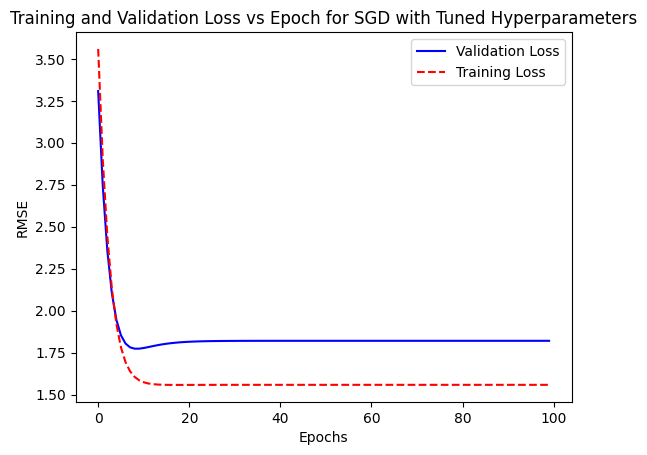

In [ ]:
plot_loss(prime_model, best_max_iter)

It looks like the model is overfitting to the training data. I will rerun the plot_loss() function for a smaller number of epochs.

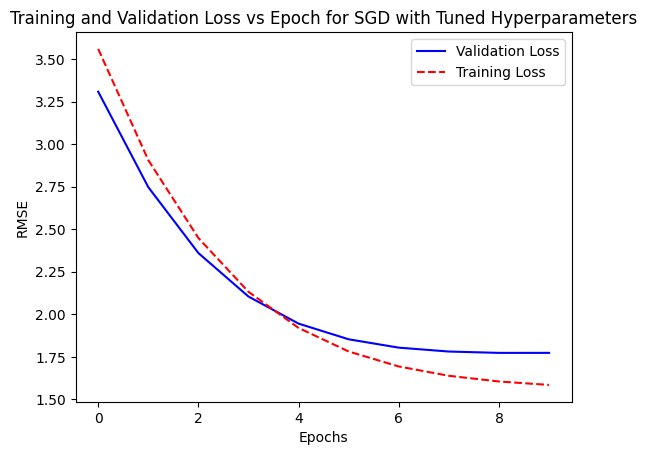

In [ ]:
plot_loss(prime_model, 10)

It looks like after about 4 epochs, the model begins to overfit.

# Part E
Repeat everything from part D with polynomial regression and using SGD. Using validation loss, explore if your model overfits/underfits the data and report your findings. Ensure reproducibility by using a seed.  [10 points]

Link to Part D cell

https://colab.research.google.com/drive/11CP5uK2LMLOu9YBLWEPNRD5mo6oHa7-i?authuser=2#scrollTo=s1f7PgW9ODqE&line=20&uniqifier=1

In [ ]:
X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

In [ ]:
POLY_DEGREES = 4 # Small because small dataset, reduce overfitting

## Closed-Form Linear Regression

In [ ]:
print("Degree\tRMSE\n")
for degree in range(POLY_DEGREES):
  print(f"{degree}\t{create_cross_validation_list(LinearRegression(), degree=degree)}")

Degree	RMSE

0	1.861
1	1.9907
2	4.6359
3	2.5682


## SGD and Variants

Hyperparameters for testing

(Copied and pasted from above. Not strictly necessary (and adds needless redundancy) but saves scrolling to refer to them.)

### Standard SGD

In [ ]:
alphas = [1e-4, 1e-2, 1]

etas = [0.001, 0.01, 0.1]
max_iters = [100, 1000, 10000]
tols = [1e-3, 1e-2, 1e-1]

In [ ]:
print("Degree\tRMSE\n")
for degree in range(POLY_DEGREES):
  print(f"{degree}\t{create_cross_validation_list(sgd_model(), degree=degree):,.4f}")

Degree	RMSE

0	1.8610
1	1.9195
2	2.1879
3	440,274,022,933.2128


Curiously, degree 0 (i.e. a constant value) seems to be the best predictor of *age* in these models. This is especially surprising to me since age generally has a normal distribution in the data, so there should not be an overly strong skew to a specific value. However, revisiting the correlation matrix, I see that it never correlated with any of the values with a strength greater than 0.45. While not necessarily weak correlations, perhaps that has something to do with it.

My hypothesis is that possums mature after only a year or two with little growth thereafter. Thus, these measurements would only correlate strongly with adolescents opposums which aren't really represented in the dataset.

Special Note: Seeing that absolutely enormous RMSE for degree 3 got a good laugh out of me.

### Ridge Regression

In [ ]:
print("degree\ta\tRMSE\n")
for degree in range(POLY_DEGREES):
  for alpha in alphas:
    print(f"{degree}\t{alpha}\t{create_cross_validation_list(ridge(alpha), degree=degree):,.4f}")
  print()


degree	a	RMSE

0	0.0001	1.8610
0	0.01	1.8611
0	1	1.8625

1	0.0001	1.9195
1	0.01	1.9128
1	1	1.7614

2	0.0001	2.1877
2	0.01	2.1707
2	1	1.7584

3	0.0001	440,293,273,069.9428
3	0.01	442,221,331,400.6277
3	1	442,664,460,020.6084



Ah, but here with ridge regression degree 2 is actually having an effect.

In [ ]:
print("degree\ta\tRMSE\n")
for degree in range(POLY_DEGREES):
  for alpha in range(6):
    print(f"{degree}\t{alpha}\t{create_cross_validation_list(ridge(alpha), degree=degree):,.4f}")
  print()

degree	a	RMSE

0	0	1.8610
0	1	1.8625
0	2	1.8613
0	3	1.8606
0	4	1.8603
0	5	1.8609

1	0	1.9195
1	1	1.7614
1	2	1.7391
1	3	1.7319
1	4	1.7340
1	5	1.7397

2	0	2.1879
2	1	1.7584
2	2	1.7190
2	3	1.7310
2	4	1.7479
2	5	1.7462

3	0	440,274,022,933.2128
3	1	442,664,460,020.6084
3	2	463,200,645,068.2020
3	3	440,866,928,806.3082
3	4	457,037,911,017.4969
3	5	247,636,659,183.3263



Fine-tuning a, the model seems to be performing best when a ≈ 2

### Lasso Regression

In [ ]:
print("degree\ta\tRMSE\n")
for degree in range(POLY_DEGREES):
  for alpha in alphas:
    print(f"{degree}\t{alpha}\t{create_cross_validation_list(lasso(alpha), degree=degree):,.4f}")
  print()

degree	a	RMSE

0	0.0001	1.8610
0	0.01	1.8610
0	1	1.8995

1	0.0001	1.9212
1	0.01	1.9064
1	1	1.8952

2	0.0001	2.1873
2	0.01	2.1336
2	1	1.9410

3	0.0001	440,377,784,154.0686
3	0.01	450,547,743,047.7542
3	1	212,353,415,647.0193



In [ ]:
print("degree\ta\tRMSE\n")
for degree in range(POLY_DEGREES):
  for alpha in range(6):
    print(f"{degree}\t{alpha}\t{create_cross_validation_list(lasso(alpha), degree=degree):,.4f}")
  print()

degree	a	RMSE

0	0	1.8610
0	1	1.8995
0	2	1.8611
0	3	1.8616
0	4	1.8616
0	5	1.8616

1	0	1.9195
1	1	1.8952
1	2	1.8611
1	3	1.8616
1	4	1.8616
1	5	1.8616

2	0	2.1879
2	1	1.9410
2	2	1.8613
2	3	1.8613
2	4	1.8616
2	5	1.8616

3	0	440,274,022,933.2128
3	1	212,353,415,647.0193
3	2	1.8973
3	3	1.8633
3	4	1.8616
3	5	1.8616



Likewise, a ≈ 2 works best for Lasso Regression.

### Elastic Net Regression

In [ ]:
ratios = [0.15, 0.5, 0.85]
print("degree\ta\tl1_ratio\tRMSE\n")
for degree in range(POLY_DEGREES):
  for alpha in range(6):
    for ratio in ratios:
      print(f"{degree}\t{alpha}\t{ratio:,.2f}\t\t{create_cross_validation_list(elastic_net(alpha, ratio), degree=degree):,.4f}")
    print()
  print("------------------------------------------")
  print("degree\ta\tl1_ratio\tRMSE\n")

degree	a	l1_ratio	RMSE

0	0	0.15		1.8610
0	0	0.50		1.8610
0	0	0.85		1.8610

0	1	0.15		1.8639
0	1	0.50		1.8614
0	1	0.85		1.8805

0	2	0.15		1.8616
0	2	0.50		1.8613
0	2	0.85		1.8613

0	3	0.15		1.8611
0	3	0.50		1.8612
0	3	0.85		1.8616

0	4	0.15		1.8614
0	4	0.50		1.8615
0	4	0.85		1.8616

0	5	0.15		1.8612
0	5	0.50		1.8613
0	5	0.85		1.8616

------------------------------------------
degree	a	l1_ratio	RMSE

1	0	0.15		1.9195
1	0	0.50		1.9195
1	0	0.85		1.9195

1	1	0.15		1.7702
1	1	0.50		1.8119
1	1	0.85		1.8741

1	2	0.15		1.7636
1	2	0.50		1.8605
1	2	0.85		1.8613

1	3	0.15		1.8003
1	3	0.50		1.8612
1	3	0.85		1.8616

1	4	0.15		1.8359
1	4	0.50		1.8615
1	4	0.85		1.8616

1	5	0.15		1.8547
1	5	0.50		1.8613
1	5	0.85		1.8616

------------------------------------------
degree	a	l1_ratio	RMSE

2	0	0.15		2.1879
2	0	0.50		2.1879
2	0	0.85		2.1879

2	1	0.15		1.7460
2	1	0.50		1.8511
2	1	0.85		1.9515

2	2	0.15		1.8094
2	2	0.50		1.9684
2	2	0.85		1.9390

2	3	0.15		1.8929
2	3	0.50		1.9227
2	3	0.85		1.8612

2	4	0.15		

The best RMSE for Elastic Net was 1.7460 with [degree = 2, a = 1, l1_ratio = 0.15].

However, this still loses to Ridge Regressions's optimal 1.7190.



## Results

Surprisingly, as with standard Linear Regression, Ridge Regression performed best with an optimal RMSE of 1.7190 using [degree = 2, a = 2]. I will continue to use these when testing the other hyperparameters.

## Exploring SGD Hyperparameters

Hyperparameter Reminders:
- eta0: learning rate
- tol: stopping criterion
- max_iter: maximum number of iterations (used when tol not met)


In [ ]:
etas = [0.001, 0.01, 0.1]
max_iters = [100, 1000, 10000]
tols = [1e-3, 1e-2, 1e-1]

best_alpha = 2
best_degree = 2
best_ratio = 0 # Ridge Regression, for reuse of existing Elastic Net model

In [ ]:
print("eta0\t\tmax_iter\ttol\t\tRMSE\n")
for eta0 in etas:
  for max_iter in max_iters:
    for tol in tols:
      print(f"{eta0}\t\t{max_iter}\t\t{tol}\t\t{create_cross_validation_list(elastic_net(best_alpha, best_ratio, eta0, max_iter, tol), degree=best_degree):,.4f}")
    print()
  print("------------------------------------------------------")
  print("eta0\t\tmax_iter\ttol\t\tRMSE\n")

eta0		max_iter	tol		RMSE

0.001		100		0.001		1.7893
0.001		100		0.01		1.8294
0.001		100		0.1		1.9843

0.001		1000		0.001		1.7894
0.001		1000		0.01		1.8294
0.001		1000		0.1		1.9843

0.001		10000		0.001		1.7894
0.001		10000		0.01		1.8294
0.001		10000		0.1		1.9843

------------------------------------------------------
eta0		max_iter	tol		RMSE

0.01		100		0.001		1.7190
0.01		100		0.01		1.7470
0.01		100		0.1		1.7695

0.01		1000		0.001		1.7190
0.01		1000		0.01		1.7470
0.01		1000		0.1		1.7695

0.01		10000		0.001		1.7190
0.01		10000		0.01		1.7470
0.01		10000		0.1		1.7695

------------------------------------------------------
eta0		max_iter	tol		RMSE

0.1		100		0.001		455,938,738,611.6492
0.1		100		0.01		455,938,738,611.6492
0.1		100		0.1		455,938,738,611.6492

0.1		1000		0.001		455,938,738,611.6492
0.1		1000		0.01		455,938,738,611.6492
0.1		1000		0.1		455,938,738,611.6492

0.1		10000		0.001		455,938,738,611.6492
0.1		10000		0.01		455,938,738,611.6492
0.1		10000		0.1		455,938,738,611.6492

--

I still can't beat the initial Ridge Regression model. The smallest RMSE is 1.7190 with parameters [eta0 = 0.01, max_iter = 100, and tol = 0.001]. However, seeing that tolerance is having a noticeable impact, I will further experiment with it for greater precision.

In [ ]:
best_eta0 = 0.01
best_max_iter = 100

tols = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

In [ ]:
print("tol\t\tRMSE\n")
for tol in tols:
  print(f"{tol}\t\t{create_cross_validation_list(elastic_net(best_alpha, best_ratio, best_eta0, best_max_iter, tol), degree=best_degree):,.4f}")
print()

tol		RMSE

0.1		1.7695
0.01		1.7470
0.001		1.7190
0.0001		1.7052
1e-05		1.7052
1e-06		1.7052



The best tolerance seems to be 1e-4. I tried increasing the number of iterations in case it needed more time but that had no effect on the final outcome. Thus, the best RMSE is now 1.7052.

In [ ]:
best_tol = 1e-4

## Training and Validation Loss vs Epochs

In [ ]:
prime_poly_model = (
    SGDRegressor(
        max_iter = best_max_iter,
        tol = best_tol,
        penalty = 'elasticnet',
        l1_ratio = best_ratio,
        alpha = best_alpha,
        eta0 = best_eta0,
        warm_start = True,
        random_state = SEED
    )
)

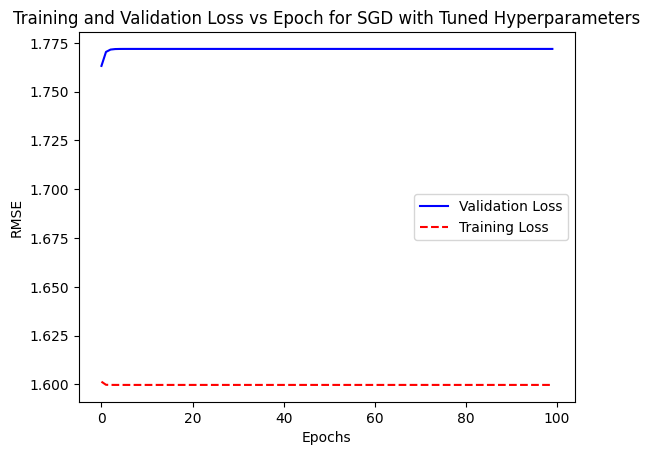

In [ ]:
plot_loss(prime_poly_model, 100)

As before, the model quickly achieves a steady state. And again as before, we will reduce the number of epochs to truly see how quickly.

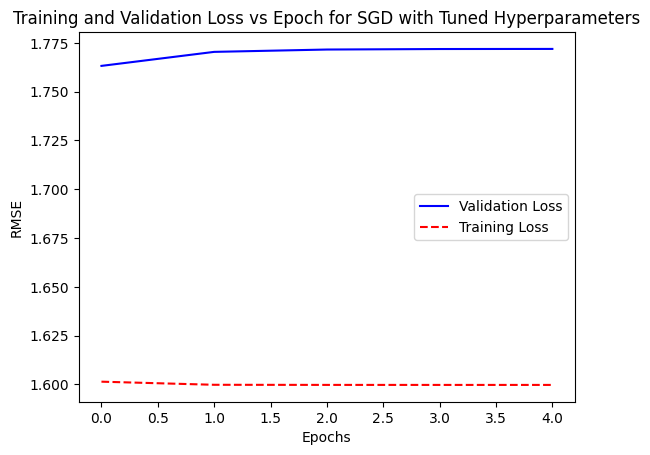

In [ ]:
plot_loss(prime_poly_model, 5)

Very quickly as it turns out! The model reaches steady state after a single epoch with a steady state around RMSE = 1.7750 on validation. However, it looks like it is overfitting the data.

# Part F
Make predictions of the labels on the test data, using the trained model with chosen (best) hyperparameters. Summarize performance using the RMSE. Three teams with the lowest RMSE (who followed correctly all the previous steps) will receive bonus points.  [10 points]

I will initially compare with the Polynomial Regression. However, given the previous loss charts, it will likely overfit. Thus, I will also compare with standard Linear Regression.

## Polynomial Regression

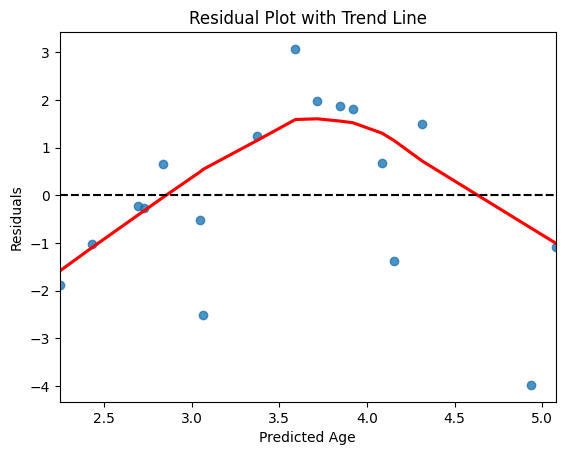

In [ ]:
residuals = y_test - y_pred

sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Residual Plot with Trend Line")
plt.show()


The trend line seems to indicate overfitting, as expected. Now for the Linear Regression model.

## Linear Regression

In [ ]:
final_model = elastic_net(best_alpha, best_ratio, best_eta0, best_max_iter, tol)

X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

poly = PolynomialFeatures(degree = 1)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

#Predict on the testing set
final_model.fit(X_train_poly, y_train)
y_pred = final_model.predict(X_test_poly)
test_rmse = root_mean_squared_error(y_test, y_pred)

print('The RMSE on the testing set for the model with the best hyperparameters is:', round(test_rmse, 4))

The RMSE on the testing set for the model with the best hyperparameters is: 1.758


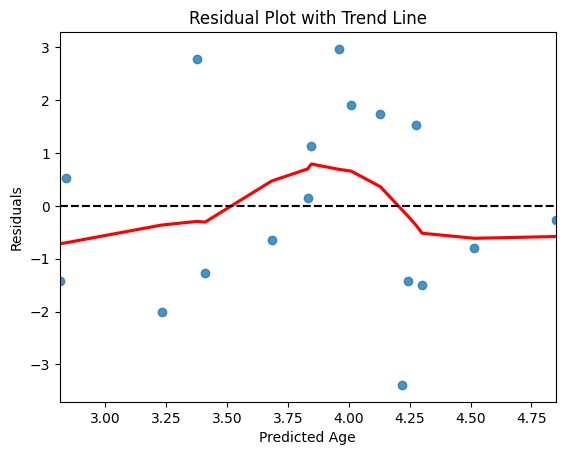

In [ ]:
residuals = y_test - y_pred

sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Residual Plot with Trend Line")
plt.show()

The standard linear regression model has an even better RMSE and a somewhat flatter trend line, suggesting that indeed the prime_poly_model was overfitting. Overall, though, I think that the dataset may be too small and that the correlation between all these different measurements and age is too weak.

Looking into my hypothesis, possums reach maturity after only 9-12 months, so there likely is very little growth after that first year to try and hone in on.

# Final Experiment

As a final experiment, I replaced the dataset with a reduced one of only male possums. I ended up with much better fits and lower RMSEs. I will revert it back so as to not rewrite the whole notebook, but it remains as a commented line in the Initialization section above

https://colab.research.google.com/drive/11CP5uK2LMLOu9YBLWEPNRD5mo6oHa7-i?authuser=2#scrollTo=iwa-UsuvTLht&line=1&uniqifier=1

# References

I referenced the scikit-learn manual at scikit-learn.org. ChatGPT also assisted in my understanding of the code as I adapted it from the group portion (Q1). However, the overall refinement, i.e. abstraction, of the code such as in testing the various hyperparameters I left to myself.